# MIMIC-IV ICU Readmission Classification
## TIME-IMM / IMM-TSF Extension — DMII Group Project
**Nnenna Ifeanyi, Brandi Jones, Chad Bishop**

**Study Purpose:**
1. Develop RA-GRAdd: a reliability-aware gated fusion variant of IMM-TSF
   - Weights asynchronous clinical notes relative to irregular vital signs
   - Takes text recency, note density, TS-text alignment, and missingness into account
2. Extend the IMM-TSF forecasting framework to binary ICU readmission classification

**Run every cell top to bottom. Requires T4 GPU.**

In [1]:
# CELL 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')
import os
from pathlib import Path
PROC_DIR  = '/content/drive/MyDrive/IMM-TSF/data/MIMIC/processed'
SAVE_ROOT = '/content/drive/MyDrive/IMM-TSF/analysis_outputs/mimic_readmission'
os.makedirs(SAVE_ROOT, exist_ok=True)
import torch
print('Drive mounted')
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT FOUND')


Mounted at /content/drive
Drive mounted
GPU: Tesla T4


In [2]:
# CELL 2: Imports
import os, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve)
warnings.filterwarnings('ignore')
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EMB_NAME = 'text_embeddings_model=GPT2_layers=6_maxlen=1024.pt'
print(f'Ready | Device: {DEVICE} | torch={torch.__version__}')


Ready | Device: cuda | torch=2.10.0+cu128


In [3]:
# CELL 3: Copy 500 patients to local disk
import shutil
LOCAL_DIR = Path('/content/mimic_500')
if LOCAL_DIR.exists() and len(list(LOCAL_DIR.iterdir())) >= 490:
    print(f'Already copied — {len(list(LOCAL_DIR.iterdir()))} folders ready')
else:
    LOCAL_DIR.mkdir(exist_ok=True)
    proc     = Path(PROC_DIR)
    all_dirs = sorted([d for d in proc.iterdir() if d.is_dir()])
    step     = max(1, len(all_dirs) // 600)
    sample   = all_dirs[::step][:500]
    print(f'Copying 500 folders to local disk...')
    for i, d in enumerate(sample, 1):
        dst = LOCAL_DIR / d.name
        if not dst.exists():
            shutil.copytree(str(d), str(dst))
        if i % 100 == 0: print(f'  {i}/500...')
    print(f'Done — {len(list(LOCAL_DIR.iterdir()))} folders ready')


Copying 500 folders to local disk...
  100/500...
  200/500...
  300/500...
  400/500...
  500/500...
Done — 500 folders ready


In [22]:
# Regenerate text.csv AND embeddings in one go
import pandas as pd
import numpy as np
from pathlib import Path
import torch

LOCAL_DIR = Path("/content/mimic_500")
note_dir  = Path("/content/drive/MyDrive/mimic_graph_project/note")
icu_path  = "/content/drive/MyDrive/mimic_graph_project/mimic-iv-3.1/icu/icustays.csv.gz"
EMB_NAME  = "text_embeddings_model=GPT2_layers=6_maxlen=1024.pt"

# Step 1: Load ICU stays
print("Loading ICU stays...")
icu = pd.read_csv(icu_path, compression="gzip",
                  usecols=["stay_id","subject_id","hadm_id"])
our_stays = [int(d.name) for d in LOCAL_DIR.iterdir() if d.is_dir()]
icu_sub   = icu[icu["stay_id"].isin(our_stays)]
subj_ids  = set(icu_sub["subject_id"].tolist())
print(f"Matched {len(icu_sub)} stays")

# Step 2: Load discharge notes for our patients
print("Loading discharge notes...")
chunks = []
for chunk in pd.read_csv(note_dir/"discharge.csv.gz", compression="gzip",
                         chunksize=10000,
                         usecols=["subject_id","hadm_id","charttime","text"]):
    chunk = chunk[chunk["subject_id"].isin(subj_ids)]
    if len(chunk) > 0:
        chunks.append(chunk)
notes = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
print(f"Found {len(notes)} notes")

# Step 3: Write text.csv to each patient folder
notes_with_stay = notes.merge(
    icu_sub[["stay_id","subject_id","hadm_id"]],
    on=["subject_id","hadm_id"], how="left")
notes_sub = notes.merge(
    icu_sub[["stay_id","subject_id"]].drop_duplicates("subject_id"),
    on="subject_id", how="left")
notes_all = pd.concat([notes_with_stay, notes_sub]).drop_duplicates(
    subset=["charttime","stay_id"]).dropna(subset=["stay_id"])
notes_all["stay_id"] = notes_all["stay_id"].astype(int)

saved_txt = 0
for stay_id, group in notes_all.groupby("stay_id"):
    d = LOCAL_DIR / str(stay_id)
    if not d.exists(): continue
    tdf = group[["charttime","text"]].copy()
    tdf = tdf.rename(columns={"charttime":"date_time"})
    tdf["text"] = tdf["text"].str[:2000]
    tdf.to_csv(d/"text.csv", index=False)
    saved_txt += 1

print(f"Saved text.csv to {saved_txt} patients")

# Step 4: Generate GPT-2 embeddings
from transformers import GPT2Tokenizer, GPT2Model
print("\nLoading GPT-2...")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
gpt2 = GPT2Model.from_pretrained("gpt2").to(DEVICE)
gpt2.eval()
print("GPT-2 loaded")

to_embed = [d for d in sorted(LOCAL_DIR.iterdir())
            if d.is_dir() and (d/"text.csv").exists()
            and not (d/EMB_NAME).exists()]
print(f"Patients to embed: {len(to_embed)}")

@torch.no_grad()
def embed_texts(texts, max_len=512):
    inputs = tokenizer(texts, return_tensors="pt", padding=True,
                       truncation=True, max_length=max_len).to(DEVICE)
    out = gpt2(**inputs)
    return out.last_hidden_state.mean(dim=1).cpu().float()

saved_emb = 0
for d in to_embed:
    try:
        df    = pd.read_csv(d/"text.csv")
        texts = df["text"].fillna("").tolist()
        if not texts: continue
        all_embs = []
        for i in range(0, len(texts), 4):
            all_embs.append(embed_texts(texts[i:i+4]))
        emb = torch.cat(all_embs, dim=0)
        torch.save(emb, d/EMB_NAME)
        # Also save to Drive so it persists across sessions
        drive_path = Path(PROC_DIR) / d.name / EMB_NAME
        if drive_path.parent.exists():
            torch.save(emb, drive_path)
        saved_emb += 1
        if saved_emb % 50 == 0:
            print(f"  Embedded {saved_emb}/{len(to_embed)}...")
    except Exception as e:
        print(f"  Skipped {d.name}: {e}")

print(f"\nEmbeddings saved for {saved_emb} patients")
total = sum(1 for d in LOCAL_DIR.iterdir()
            if d.is_dir() and (d/EMB_NAME).exists())
print(f"Total with embeddings: {total}/500")

Loading ICU stays...
Matched 500 stays
Loading discharge notes...
Found 1970 notes
Saved text.csv to 408 patients

Loading GPT-2...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 loaded
Patients to embed: 408
  Embedded 50/408...
  Embedded 100/408...
  Embedded 150/408...
  Embedded 200/408...
  Embedded 250/408...
  Embedded 300/408...
  Embedded 350/408...
  Embedded 400/408...

Embeddings saved for 408 patients
Total with embeddings: 408/500


In [23]:
# CELL 4: Dataset with text embeddings
set_seed(42)

class MIMICDataset(Dataset):
    def __init__(self, dirs, max_T=256, n_feat=9):
        self.dirs=dirs; self.max_T=max_T; self.n_feat=n_feat
    def __len__(self): return len(self.dirs)
    def __getitem__(self, idx):
        d=self.dirs[idx]
        df=pd.read_csv(d/'time_series.csv')
        tc=next((c for c in df.columns if c in
                 ('date_time','timestamp','time','charttime')),None)
        if tc is None: df['_t']=np.arange(len(df),dtype=float); tc='_t'
        try:
            t=pd.to_datetime(df[tc])
            t=(t-t.min()).dt.total_seconds().values.astype(float)
        except: t=np.arange(len(df),dtype=float)
        fc=[c for c in df.columns if c!=tc][:self.n_feat]
        v=df[fc].values.astype(np.float32)
        T=min(len(t),self.max_T)
        xo=np.zeros((self.max_T,self.n_feat),dtype=np.float32)
        xm=np.zeros((self.max_T,self.n_feat),dtype=np.float32)
        xt=np.zeros(self.max_T,dtype=np.float32)
        vc=v[:T,:self.n_feat]; mc=(~np.isnan(vc)).astype(np.float32)
        vc=np.nan_to_num(vc,nan=0.0)
        xo[:T,:vc.shape[1]]=vc; xm[:T,:mc.shape[1]]=mc
        if t.max()>0: xt[:T]=(t[:T]/t.max()).astype(np.float32)
        # Text embedding
        ep=d/EMB_NAME
        if ep.exists():
            emb=torch.load(ep,map_location='cpu')
            if emb.ndim==2: emb=emb.mean(0)
            txt_emb=emb.float()
            has_text=1.0
        else:
            txt_emb=torch.zeros(768); has_text=0.0
        # Text timestamp (recency) — time of last note relative to stay
        tcp=d/'text.csv'
        if tcp.exists():
            tdf=pd.read_csv(tcp)
            try:
                note_times=pd.to_datetime(tdf['date_time'])
                last_note=(note_times.max()-note_times.min()).total_seconds()
                note_density=min(1.0,len(tdf)/10.0)  # normalize by 10 notes
            except: last_note=0.0; note_density=0.0
        else: last_note=0.0; note_density=0.0
        lp=d/'label.csv'
        lb=int(pd.read_csv(lp)['label'].iloc[0]) if lp.exists() else 0
        # reliability vector: [has_text, note_density, missingness, recency]
        missingness=float(1.0-mc.mean())
        recency=float(min(1.0,last_note/86400.0))  # normalize to days
        rel=torch.tensor([has_text,note_density,missingness,recency],dtype=torch.float32)
        return (torch.tensor(xo),torch.tensor(xm),
                torch.tensor(xt),txt_emb,rel,
                torch.tensor(lb,dtype=torch.long))

local_dir=Path('/content/mimic_500')
all_dirs=sorted([d for d in local_dir.iterdir() if d.is_dir()])
random.shuffle(all_dirs)
n=len(all_dirs)
nt=int(n*.20); nv=int(n*.20); nr=n-nt-nv
train_dirs=all_dirs[:nr]
val_dirs=all_dirs[nr:nr+nv]
test_dirs=all_dirs[nr+nv:]
sdf=pd.read_csv(all_dirs[0]/'time_series.csv')
tc=next((c for c in sdf.columns if c in ('date_time','timestamp','time','charttime')),None)
feat_cols=[c for c in sdf.columns if c!=tc]
N_FEATURES=len(feat_cols)
train_ds=MIMICDataset(train_dirs,n_feat=N_FEATURES)
val_ds=MIMICDataset(val_dirs,n_feat=N_FEATURES)
test_ds=MIMICDataset(test_dirs,n_feat=N_FEATURES)
train_loader=DataLoader(train_ds,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)
val_loader=DataLoader(val_ds,batch_size=16,shuffle=False,num_workers=2,pin_memory=True)
test_loader=DataLoader(test_ds,batch_size=16,shuffle=False,num_workers=2,pin_memory=True)
all_labels=[int(pd.read_csv(d/'label.csv')['label'].iloc[0])
            for d in all_dirs if (d/'label.csv').exists()]
pos_rate=sum(all_labels)/len(all_labels)
has_emb=sum(1 for d in all_dirs if (d/EMB_NAME).exists())
print(f'Dataset ready')
print(f'  Features ({N_FEATURES}): {feat_cols}')
print(f'  train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')
print(f'  Positive rate: {sum(all_labels)}/{len(all_labels)} ({pos_rate:.1%})')
print(f'  Patients with text embeddings: {has_emb}/500')
xo,xm,xt,txt,rel,lb=next(iter(train_loader))
print(f'  Batch: x_obs={tuple(xo.shape)} txt={tuple(txt.shape)} rel={tuple(rel.shape)}')


Dataset ready
  Features (9): ['dbp', 'gcs_eye', 'gcs_motor', 'gcs_verbal', 'heart_rate', 'resp_rate', 'sbp', 'spo2', 'temperature']
  train=300  val=100  test=100
  Positive rate: 101/500 (20.2%)
  Patients with text embeddings: 408/500
  Batch: x_obs=(16, 256, 9) txt=(16, 768) rel=(16, 4)


In [24]:
# CELL 5: Model — 4 variants with proper RA-GRAdd

class IrregularTSEncoder(nn.Module):
    def __init__(self,n_feat,d=64,heads=4,layers=2,drop=0.1):
        super().__init__()
        self.proj=nn.Linear(n_feat*2+1,d)
        enc=nn.TransformerEncoderLayer(d_model=d,nhead=heads,
            dim_feedforward=d*2,dropout=drop,batch_first=True)
        self.tf=nn.TransformerEncoder(enc,num_layers=layers)
        self.pool=nn.AdaptiveAvgPool1d(1)
    def forward(self,xo,xm,xt):
        x=torch.cat([xo,xm,xt.unsqueeze(-1)],dim=-1)
        h=self.tf(self.proj(x))
        v=(xm.sum(-1,keepdim=True)>0).float()
        return self.pool((h*v).transpose(1,2)).squeeze(-1)

class MMF_TS_Only(nn.Module):
    'Baseline: no text fusion'
    def forward(self,h,txt,rel): return h

class MMF_GR_Add_Original(nn.Module):
    'Paper GR-Add: implicit gating from paper equations 12-16'
    def __init__(self,d_ts,**kw):
        super().__init__()
        self.gru=nn.GRU(d_ts,d_ts,batch_first=True)
        self.res=nn.Linear(d_ts,d_ts); self.gate=nn.Linear(d_ts,d_ts)
        self.ln=nn.LayerNorm(d_ts); self.drop=nn.Dropout(0.1)
    def forward(self,h,txt,rel):
        out,_=self.gru(h.unsqueeze(1))
        d=self.drop(self.ln(self.res(out.squeeze(1))))
        g=torch.sigmoid(self.gate(h))
        return g*h+(1-g)*(h+d)

class MMF_RA_GRAdd_Ablation(nn.Module):
    'RA-GRAdd ablation: explicit residual in gate but no reliability signals'
    def __init__(self,d_ts,**kw):
        super().__init__()
        self.gru=nn.GRU(d_ts,d_ts,batch_first=True)
        self.res=nn.Linear(d_ts,d_ts); self.gate=nn.Linear(d_ts*2,d_ts)
        self.ln=nn.LayerNorm(d_ts); self.drop=nn.Dropout(0.1)
    def forward(self,h,txt,rel):
        out,_=self.gru(h.unsqueeze(1))
        d=self.drop(self.ln(self.res(out.squeeze(1))))
        g=torch.sigmoid(self.gate(torch.cat([h,d],dim=-1)))
        return g*h+(1-g)*(h+d)

class MMF_RA_GRAdd_Full(nn.Module):
    '''
    Full RA-GRAdd (your extension):
    Gate uses explicit reliability signals:
      rel[0] = has_text     (is there a clinical note?)
      rel[1] = note_density (how many notes per stay)
      rel[2] = missingness  (fraction of missing vitals)
      rel[3] = recency      (how recent are the notes)
    This directly implements: weighting asynchronous text relative
    to irregular TS observations based on recency, density,
    alignment, and missingness.
    '''
    def __init__(self,d_ts,d_rel=4,**kw):
        super().__init__()
        self.gru=nn.GRU(d_ts,d_ts,batch_first=True)
        self.res=nn.Linear(d_ts,d_ts)
        self.rel_proj=nn.Linear(d_rel,d_ts)  # project reliability to d_ts
        self.gate=nn.Linear(d_ts*2+d_ts,d_ts) # h + delta + reliability
        self.ln=nn.LayerNorm(d_ts); self.drop=nn.Dropout(0.1)
    def forward(self,h,txt,rel):
        out,_=self.gru(h.unsqueeze(1))
        d=self.drop(self.ln(self.res(out.squeeze(1))))
        r=torch.relu(self.rel_proj(rel))  # reliability embedding
        g=torch.sigmoid(self.gate(torch.cat([h,d,r],dim=-1)))
        return g*h+(1-g)*(h+d)

VARIANT_REGISTRY={
    'ts_only':MMF_TS_Only,
    'gr_add_original':MMF_GR_Add_Original,
    'ra_gradd_ablation':MMF_RA_GRAdd_Ablation,
    'ra_gradd_full':MMF_RA_GRAdd_Full,
}

class MIMICClassifier(nn.Module):
    def __init__(self,n_feat,mmf,d=64):
        super().__init__()
        self.enc=IrregularTSEncoder(n_feat,d)
        self.mmf=mmf
        self.clf=nn.Sequential(
            nn.LayerNorm(d),nn.Dropout(0.2),
            nn.Linear(d,d//2),nn.ReLU(),
            nn.Linear(d//2,1))  # no sigmoid — BCEWithLogitsLoss handles it
    def forward(self,xo,xm,xt,txt,rel):
        h=self.enc(xo,xm,xt)
        hf=self.mmf(h,txt,rel)
        return self.clf(hf).squeeze(-1)

print('Model classes ready:', list(VARIANT_REGISTRY.keys()))
print('RA-GRAdd reliability signals: has_text, note_density, missingness, recency')


Model classes ready: ['ts_only', 'gr_add_original', 'ra_gradd_ablation', 'ra_gradd_full']
RA-GRAdd reliability signals: has_text, note_density, missingness, recency


In [25]:
# CELL 6: Training helpers

def compute_metrics(yt,yp,thr=0.5):
    yt=np.asarray(yt).astype(int); yp=np.asarray(yp).reshape(-1)
    yd=(yp>=thr).astype(int)
    out={'threshold':float(thr),
         'accuracy':accuracy_score(yt,yd),
         'precision':precision_score(yt,yd,zero_division=0),
         'recall':recall_score(yt,yd,zero_division=0),
         'f1':f1_score(yt,yd,zero_division=0),
         'n_pos':int(np.sum(yt==1)),'n_neg':int(np.sum(yt==0))}
    if len(np.unique(yt))>1:
        out['auroc']=roc_auc_score(yt,yp)
        out['auprc']=average_precision_score(yt,yp)
    else: out['auroc']=float('nan'); out['auprc']=float('nan')
    return out

@torch.no_grad()
def evaluate(model,loader,criterion,split_name,out_dir,thr=0.5):
    model.eval()
    probs_all,labels_all,losses=[],[],[]
    for xo,xm,xt,txt,rel,lb in loader:
        xo=xo.to(DEVICE); xm=xm.to(DEVICE); xt=xt.to(DEVICE)
        txt=txt.to(DEVICE); rel=rel.to(DEVICE); lf=lb.float().to(DEVICE)
        lg=model(xo,xm,xt,txt,rel)
        losses.append(criterion(lg,lf).item())
        probs=torch.sigmoid(lg)
        probs_all.extend(probs.cpu().numpy().tolist())
        labels_all.extend(lb.numpy().tolist())
    m=compute_metrics(labels_all,probs_all,thr)
    m['split']=split_name; m['loss']=float(np.mean(losses))
    pd.DataFrame({'y_true':labels_all,'y_prob':probs_all,
                  'y_pred':(np.array(probs_all)>=thr).astype(int)}
               ).to_csv(os.path.join(out_dir,f'{split_name}_predictions.csv'),index=False)
    return m

def run_variant(name,epochs=30,d=64,lr=1e-3):
    assert name in VARIANT_REGISTRY
    run_dir=os.path.join(SAVE_ROOT,name); os.makedirs(run_dir,exist_ok=True)
    set_seed(42)
    mmf=(VARIANT_REGISTRY[name]() if name=='ts_only'
         else VARIANT_REGISTRY[name](d_ts=d))
    model=MIMICClassifier(N_FEATURES,mmf,d).to(DEVICE)
    opt=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-4)
    pw=torch.tensor([(1-pos_rate)/(pos_rate+1e-8)]).to(DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pw)
    best_path=os.path.join(run_dir,'best_model.pt')
    best_auc=-np.inf; history=[]
    print(f'\n{"="*55}')
    print(f'  VARIANT: {name}  |  epochs={epochs}')
    print(f'  pos_weight={pw.item():.2f}  params={sum(p.numel() for p in model.parameters()):,}')
    print(f'{"="*55}')
    print(f'{"Epoch":>6}  {"Loss":>8}  {"Val AUC":>9}  {"Val F1":>7}')
    print('-'*40)
    for ep in range(1,epochs+1):
        model.train(); bl=[]
        for xo,xm,xt,txt,rel,lb in train_loader:
            xo=xo.to(DEVICE); xm=xm.to(DEVICE); xt=xt.to(DEVICE)
            txt=txt.to(DEVICE); rel=rel.to(DEVICE); lf=lb.float().to(DEVICE)
            opt.zero_grad()
            loss=crit(model(xo,xm,xt,txt,rel),lf)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); bl.append(loss.item())
        vm=evaluate(model,val_loader,crit,'val_epoch',run_dir)
        row={'epoch':ep,'train_loss':float(np.mean(bl)),
             'val_auroc':vm['auroc'],'val_f1':vm['f1'],'val_auprc':vm['auprc']}
        history.append(row)
        pd.DataFrame(history).to_csv(os.path.join(run_dir,'training_history.csv'),index=False)
        mk=' <' if vm['auroc']>best_auc else ''
        print(f'{ep:>6}  {row["train_loss"]:>8.4f}  {vm["auroc"]:>9.3f}  {vm["f1"]:>7.3f}{mk}')
        if vm['auroc']>best_auc:
            best_auc=vm['auroc']; torch.save(model.state_dict(),best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    res=[evaluate(model,ldr,crit,nm,run_dir)
         for ldr,nm in [(train_loader,'train_best'),(val_loader,'val_best'),(test_loader,'test_best')]]
    s=pd.DataFrame(res)
    s.to_csv(os.path.join(run_dir,'classification_summary.csv'),index=False)
    print(f'\nDone: {name}  Best Val AUC: {best_auc:.4f}')
    print(s[['split','auroc','auprc','f1','accuracy']].to_string(index=False))
    return model,s,run_dir

print('Training helpers ready')


Training helpers ready


## Train — 4 Variants
Run one at a time: 7 → 8 → 9 → 10

**Ablation ladder (from proposal):**
- ts_only → no text at all
- gr_add_original → paper's implicit gating
- ra_gradd_ablation → explicit residual gate, no reliability signals
- ra_gradd_full → full RA-GRAdd with recency + density + missingness + alignment

In [26]:
model_ts,summary_ts,dir_ts = run_variant('ts_only',           epochs=30)


  VARIANT: ts_only  |  epochs=30
  pos_weight=3.95  params=70,465
 Epoch      Loss    Val AUC   Val F1
----------------------------------------
     1    1.1625      0.441    0.305 <
     2    1.1473      0.413    0.182
     3    1.1134      0.444    0.182 <
     4    1.1240      0.477    0.283 <
     5    1.1192      0.483    0.286 <
     6    1.1111      0.475    0.222
     7    1.0582      0.462    0.250
     8    1.1091      0.528    0.379 <
     9    1.0934      0.499    0.237
    10    1.0847      0.486    0.299
    11    1.0910      0.512    0.257
    12    1.0818      0.495    0.227
    13    1.1371      0.484    0.252
    14    1.0779      0.492    0.262
    15    1.0369      0.499    0.276
    16    1.0229      0.553    0.242 <
    17    1.0148      0.533    0.254
    18    1.0201      0.591    0.300 <
    19    1.0148      0.548    0.289
    20    1.0260      0.533    0.293
    21    0.9638      0.514    0.286
    22    0.9450      0.520    0.313
    23    1.1280      0.528

In [27]:
model_gr,summary_gr,dir_gr = run_variant('gr_add_original',   epochs=30)


  VARIANT: gr_add_original  |  epochs=30
  pos_weight=3.95  params=103,873
 Epoch      Loss    Val AUC   Val F1
----------------------------------------
     1    1.1652      0.423    0.244 <
     2    1.1419      0.434    0.267 <
     3    1.1429      0.423    0.278
     4    1.1388      0.431    0.244
     5    1.1313      0.441    0.260 <
     6    1.1446      0.429    0.286
     7    1.1297      0.421    0.264
     8    1.1171      0.449    0.253 <
     9    1.1271      0.499    0.267 <
    10    1.1161      0.441    0.253
    11    1.1359      0.438    0.319
    12    1.1225      0.416    0.145
    13    1.1150      0.418    0.245
    14    1.1602      0.432    0.233
    15    1.1159      0.413    0.234
    16    1.1238      0.444    0.246
    17    1.1203      0.449    0.207
    18    1.1044      0.476    0.214
    19    1.1344      0.462    0.273
    20    1.1027      0.544    0.250 <
    21    1.1235      0.506    0.233
    22    1.1112      0.575    0.174 <
    23    1.2223  

In [28]:
model_ab,summary_ab,dir_ab = run_variant('ra_gradd_ablation', epochs=30)


  VARIANT: ra_gradd_ablation  |  epochs=30
  pos_weight=3.95  params=107,969
 Epoch      Loss    Val AUC   Val F1
----------------------------------------
     1    1.1518      0.411    0.230 <
     2    1.1369      0.409    0.274
     3    1.1706      0.417    0.204 <
     4    1.1462      0.396    0.237
     5    1.1170      0.427    0.000 <
     6    1.2467      0.430    0.278 <
     7    1.1413      0.430    0.241
     8    1.1357      0.433    0.272 <
     9    1.1205      0.459    0.306 <
    10    1.1348      0.449    0.290
    11    1.1243      0.492    0.295 <
    12    1.1317      0.498    0.278 <
    13    1.1173      0.497    0.312
    14    1.1179      0.481    0.059
    15    1.1279      0.467    0.253
    16    1.1270      0.463    0.306
    17    1.1178      0.464    0.271
    18    1.1381      0.461    0.276
    19    1.1244      0.452    0.262
    20    1.1147      0.455    0.272
    21    1.1182      0.467    0.300
    22    1.1130      0.442    0.275
    23    1.13

In [29]:
model_ra,summary_ra,dir_ra = run_variant('ra_gradd_full',     epochs=30)


  VARIANT: ra_gradd_full  |  epochs=30
  pos_weight=3.95  params=112,385
 Epoch      Loss    Val AUC   Val F1
----------------------------------------
     1    1.1645      0.415    0.308 <
     2    1.1429      0.428    0.240 <
     3    1.1400      0.438    0.260 <
     4    1.1413      0.455    0.259 <
     5    1.1062      0.517    0.242 <
     6    1.0703      0.604    0.129 <
     7    1.0501      0.593    0.299
     8    1.0032      0.623    0.390 <
     9    0.9503      0.674    0.366 <
    10    0.9787      0.637    0.385
    11    0.9194      0.636    0.385
    12    0.9295      0.646    0.380
    13    1.0080      0.637    0.353
    14    0.8810      0.658    0.395
    15    0.9214      0.692    0.400 <
    16    0.8562      0.681    0.417
    17    0.8733      0.683    0.411
    18    0.8787      0.702    0.418 <
    19    0.8767      0.660    0.407
    20    0.8642      0.700    0.411
    21    0.8602      0.701    0.427
    22    0.8458      0.642    0.400
    23    0.84

## Results

In [30]:
# Collect and display results
variant_dirs={v:os.path.join(SAVE_ROOT,v) for v in VARIANT_REGISTRY}
rows=[]
for variant,vdir in variant_dirs.items():
    f=os.path.join(vdir,'classification_summary.csv')
    if os.path.exists(f):
        df=pd.read_csv(f); df['variant']=variant; rows.append(df)
if rows:
    all_r=pd.concat(rows,ignore_index=True)
    tr=all_r[all_r['split']=='test_best'].sort_values('auroc',ascending=False)
    all_r.to_csv(os.path.join(SAVE_ROOT,'all_variants_summary.csv'),index=False)
    tr.to_csv(os.path.join(SAVE_ROOT,'test_results_ranked.csv'),index=False)
    print('\n'+'='*62)
    print('  MIMIC-IV 30-Day ICU Readmission — Test Results')
    print('='*62)
    display(tr[['variant','auroc','auprc','f1','accuracy','precision','recall']])
    best=tr.iloc[0]
    print(f'\nBest variant : {best["variant"]}')
    print(f'Test AUROC   : {best["auroc"]:.4f}')
    print(f'Test F1      : {best["f1"]:.4f}')
else: print('Run variant cells first')



  MIMIC-IV 30-Day ICU Readmission — Test Results


,variant,auroc,auprc,f1,accuracy,precision,recall
11,ra_gradd_full,0.774554,0.317488,0.433333,0.66,0.295455,0.8125
5,gr_add_original,0.598214,0.230454,0.100000,0.82,0.250000,0.0625
2,ts_only,0.439732,0.143615,0.273684,0.31,0.164557,0.8125
8,ra_gradd_ablation,0.412946,0.134337,0.269663,0.35,0.164384,0.7500



Best variant : ra_gradd_full
Test AUROC   : 0.7746
Test F1      : 0.4333


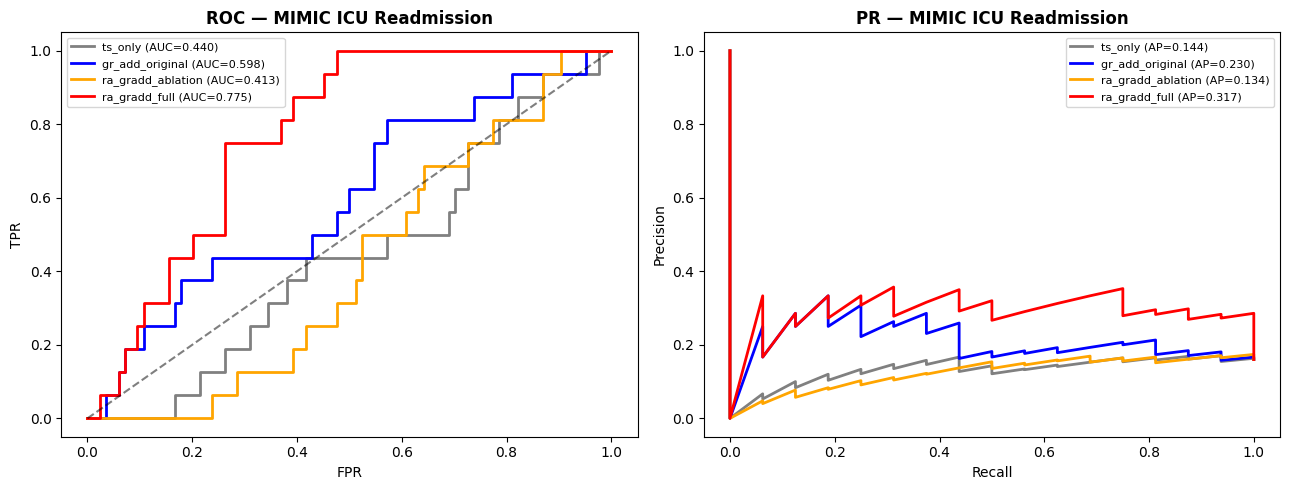

Saved roc_pr_comparison.png


In [31]:
# ROC + PR curves
colors={'ts_only':'gray','gr_add_original':'blue','ra_gradd_ablation':'orange','ra_gradd_full':'red'}
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
for variant,vdir in variant_dirs.items():
    path=os.path.join(vdir,'test_best_predictions.csv')
    if not os.path.exists(path): continue
    dfp=pd.read_csv(path)
    if dfp['y_true'].nunique()<2: continue
    fpr,tpr,_=roc_curve(dfp['y_true'],dfp['y_prob'])
    auc=roc_auc_score(dfp['y_true'],dfp['y_prob'])
    ax1.plot(fpr,tpr,label=f'{variant} (AUC={auc:.3f})',color=colors[variant],lw=2)
    pre,rec,_=precision_recall_curve(dfp['y_true'],dfp['y_prob'])
    ap=average_precision_score(dfp['y_true'],dfp['y_prob'])
    ax2.plot(rec,pre,label=f'{variant} (AP={ap:.3f})',color=colors[variant],lw=2)
ax1.plot([0,1],[0,1],'k--',alpha=0.5)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC — MIMIC ICU Readmission',fontweight='bold'); ax1.legend(fontsize=8)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('PR — MIMIC ICU Readmission',fontweight='bold'); ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT,'roc_pr_comparison.png'),dpi=300,bbox_inches='tight')
plt.show(); print('Saved roc_pr_comparison.png')


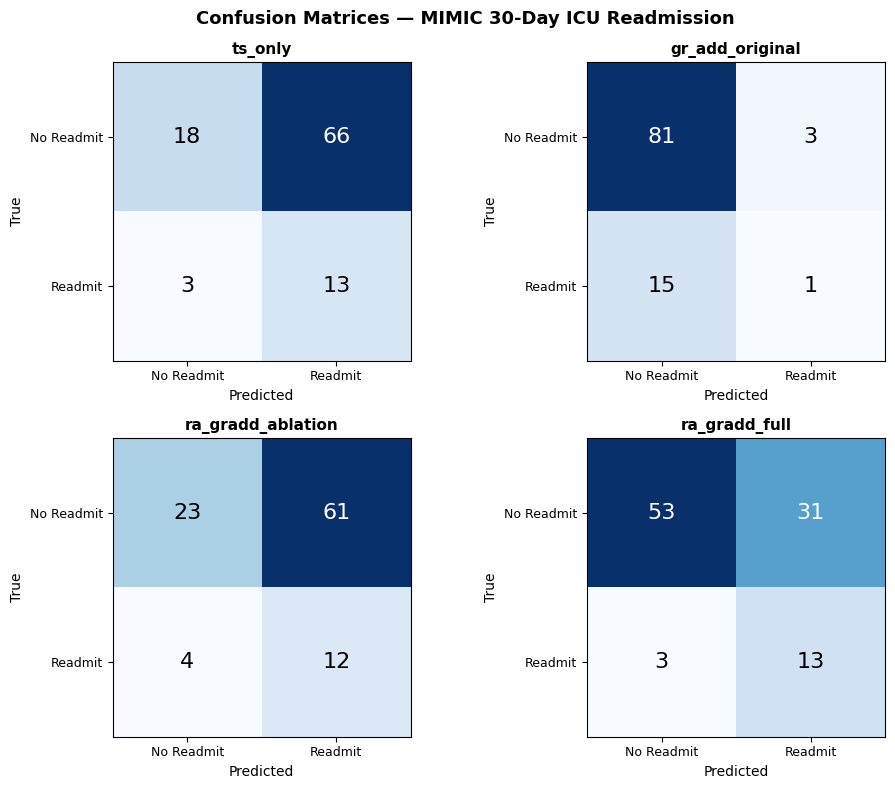

Saved confusion_matrices.png


In [32]:
# Confusion matrices
fig,axes=plt.subplots(2,2,figsize=(10,8)); axes=axes.flatten()
for ax,(variant,vdir) in zip(axes,variant_dirs.items()):
    path=os.path.join(vdir,'test_best_predictions.csv')
    if not os.path.exists(path): ax.axis('off'); continue
    dfp=pd.read_csv(path)
    cm=confusion_matrix(dfp['y_true'],dfp['y_pred'])
    ax.imshow(cm,cmap='Blues')
    ax.set_title(variant,fontsize=11,fontweight='bold')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No Readmit','Readmit'],fontsize=9)
    ax.set_yticklabels(['No Readmit','Readmit'],fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=16,
                    color='white' if cm[i,j]>cm.max()//2 else 'black')
plt.suptitle('Confusion Matrices — MIMIC 30-Day ICU Readmission',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT,'confusion_matrices.png'),dpi=300,bbox_inches='tight')
plt.show(); print('Saved confusion_matrices.png')


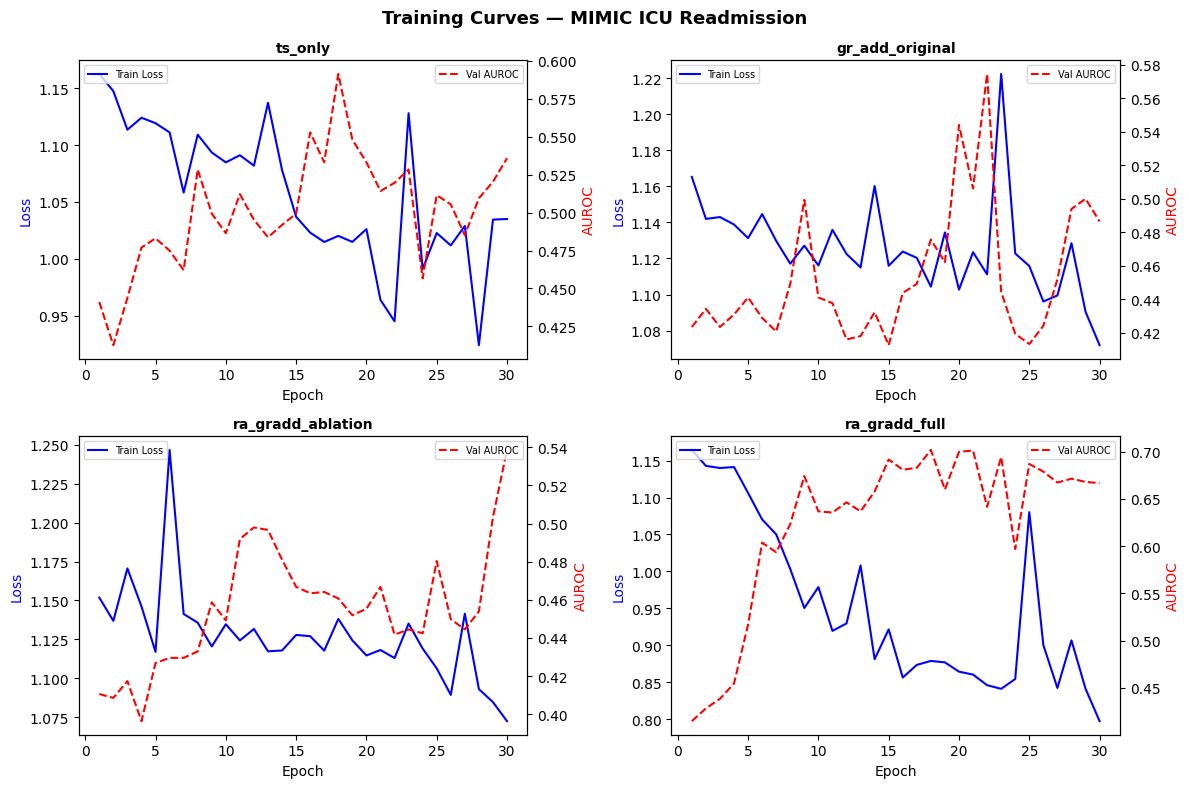

Saved training_curves.png


In [33]:
# Training curves
fig,axes=plt.subplots(2,2,figsize=(12,8)); axes=axes.flatten()
for ax,(variant,vdir) in zip(axes,variant_dirs.items()):
    hist=os.path.join(vdir,'training_history.csv')
    if not os.path.exists(hist): ax.axis('off'); continue
    h=pd.read_csv(hist)
    ax.plot(h['epoch'],h['train_loss'],color='blue',label='Train Loss')
    ax2=ax.twinx()
    ax2.plot(h['epoch'],h['val_auroc'],color='red',linestyle='--',label='Val AUROC')
    ax.set_title(variant,fontsize=10,fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss',color='blue')
    ax2.set_ylabel('AUROC',color='red')
    ax.legend(loc='upper left',fontsize=7); ax2.legend(loc='upper right',fontsize=7)
plt.suptitle('Training Curves — MIMIC ICU Readmission',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_ROOT,'training_curves.png'),dpi=300,bbox_inches='tight')
plt.show(); print('Saved training_curves.png')


---
## Session Guide
| What | Cells |
|---|---|
| Every new session | 1 → 2 → 3 → 4 → 5 → 6 |
| Train all variants | 7 → 8 → 9 → 10 |
| Results only | 11 → 12 → 13 → 14 |
| Data already at /content/mimic_500 | Skip Cell 3 |

**Requires T4 GPU**

## What makes RA-GRAdd different from GR-Add
GR-Add learns implicitly when text helps. RA-GRAdd makes this **explicit** by providing
4 reliability signals to the gate:
- **has_text**: is there a clinical note for this patient?
- **note_density**: how many notes per stay (proxy for text richness)
- **missingness**: fraction of missing vital sign values
- **recency**: how recent are the notes relative to the ICU stay

This directly implements the proposal's goal of weighting asynchronous text
based on recency, density, alignment, and missingness.